## Python for DS Week-2 Notebook

### Table of Content
1.  **[Concatenate](#Concatenate)**
2.  **[Merging and Joining](#Merging)**
3.  **[Reshaping](#Reshaping)**
4.  **[Duplicate](#Duplicate)**
5.  **[Dropping Rows and Columns](#drop)**
6.  **[Rename](#Rename)**
7.  **[Map and Replace](#Map)**
8.  **[Value Counts](#Value_Counts)**
9.  **[Pivot Table](#Pivote)**
10.  **[Cross Table](#crosst)**
11. **[Groupby in Pandas](#Groupby)**
12. **[Summary Statistics](#Summary_Statistics)**
13. **[Date-Time-Functions](#Datetime)**
14. **[to_csv](#to_csv)**
15. **[Plots using Matplotlib ](#matplotlib)**
16. **[Plots using Seaborn ](#seaborn)**
17. **[Plots using Plotly(3D Plots)](#plotly)**

<a id="Concatenate"> </a>
### 1. Concatenate

Concatenation is a process of joining objects along a particular axis, with set logic applied along the other axes.

**Concatenating DataFrames**

To concatenate DataFrames, let us first create three DataFrame
1. df_prof_info_2024: professional information on employees of year 2024
2. df_prof_info_2025: professional information on employees of year 2025
3. df_pers_info_2024: personal information on employees of year 2024
4. df_pers_info_2025: personal information on employees of year 2025


In [329]:
# create a DataFrame from a dictionary
df_prof_info_2024 = pd.DataFrame({
   'Emp_ID': [1001,1002,1003,1004,1005],
   'Name': ['Alex', 'Amy', 'Allen', 'Alice', 'Stephan'],
   'Gender':['M', 'F', 'M', 'F', 'M'],
   'Salary':[67000,90000,87000,69000,78000]})


# create a DataFrame from a dictionary
df_prof_info_2025 = pd.DataFrame({
    'Emp_ID': [1006,1007,1008,1009,1010,1011],
   'Name': ['Billy', 'Brian', 'Bran', 'Bryce', 'Betty','James'],
    'Gender':['M', 'M', 'M', 'F', 'F','M'],
   'Salary':[89000,80000,79000,97000,88000,89000]})


# create a DataFrame from a dictionary
df_pers_info_2024 = pd.DataFrame({
     'Emp_ID': [1001,1002,1003,1004,1005],
   'Hometown': ['New York', 'London', 'San Francisco', 'Seattle', 'Madrid'],
    'Marital':['Married','Divorsed','Single','Married','Single'],
   'Dependents':[1,1,3,2,1]})


# create a DataFrame from a dictionary
df_pers_info_2025 = pd.DataFrame({
     'Emp_ID': [1006,1007,1008,1009,1010,1011],
   'Hometown': ['Paris', 'Boston', 'San Francisco', 'Seattle', 'London','London'],
    'Marital':['Married','Divorsed','Single','Married','Single','Single'],
   'Dependents':[1,1,3,2,1,2]})



**Concatenating pandas DataFrames using `.concat()`**

**Combine DataFrames vertically**
##### Logic we want combine the employee details of both the years

In [11]:
pd.concat([df_prof_info_2024,df_prof_info_2025])

,Emp_ID,Name,Gender,Salary
0,1001,Alex,M,67000
1,1002,Amy,F,90000
2,1003,Allen,M,87000
3,1004,Alice,F,69000
4,1005,Stephan,M,78000
0,1006,Billy,M,89000
1,1007,Brian,M,80000
2,1008,Bran,M,79000
3,1009,Bryce,F,97000
4,1010,Betty,F,88000


In [15]:
# We can apply the same logic to personal details from both years

**Combine DataFrames horizontally**
##### We want to combine the prof details and personal details of employeees from year 2024

In [14]:
# combine Pandas Dataframes horizontally
# axis specifies the axis to concatenate along, here 1 indicates columns
pd.concat([df_prof_info_2024, df_pers_info_2024], axis=1)

,Emp_ID,Name,Gender,Salary,Emp_ID,Hometown,Marital,Dependents
0,1001,Alex,M,67000,1001,New York,Married,1
1,1002,Amy,F,90000,1002,London,Divorsed,1
2,1003,Allen,M,87000,1003,San Francisco,Single,3
3,1004,Alice,F,69000,1004,Seattle,Married,2
4,1005,Stephan,M,78000,1005,Madrid,Single,1


In [16]:
# We can apply the same logic to combine professional details & personal details of year 2025

<a id="Merging"> </a>
### 2. Merging and Joining

Merging two datasets is a process of bringing two datasets to form one, by aligning the rows from both the datasets based on common attributes or columns

### Concatenate using `.merge()`

**`merge()` allows you to perform inner join, left join, right join, and full outer join in pandas.**

**Understanding the Different Types of Merge:**

Inner join: includes those rows that are common to both the DataFrames. (how=‘inner’).

Left outer join: includes all the rows of your DataFrame x and only those from y that match. (how=‘left’).

Right outer join: includes all the rows of your DataFrame y and only those from x that match. (how=‘right’).

Full outer join: includes all rows from both DataFrames. (how=‘outer’).

In [132]:
import pandas as pd

# Table 1: Professional Details
prof_data = {
    'emp_id': ['E101', 'E102', 'E103', 'E104', 'E105', 'E106'],
    'salary': [55000, 72000, 95000, 48000, 60000, 85000],
    'experience': ['3 years', '5 years', '8 years', '2 years', '4 years', '7 years'],
    'designation': ['Associate', 'Manager', 'Senior Manager', 'Associate', 'Manager', 'Senior Manager']
}

# Table 2: Personal Details
personal_data = {
    'emp_id': ['E101', 'E103', 'E104', 'E107', 'E108'],
    'gender': ['Male', 'Female', 'Male', 'Female', 'Male'],
    'phone_number': [9876543210, 8765432109, 7654321098, 6543210987, 5432109876]
}

# Creating DataFrames
df_prof = pd.DataFrame(prof_data)
df_personal = pd.DataFrame(personal_data)


**Inner Join:**<br>
It returns only the rows in which the left table has matching keys in the right table.

In [135]:
pd.merge(left=df_prof,right=df_personal,how='inner')

,emp_id,salary,experience,designation,gender,phone_number
0,E101,55000,3 years,Associate,Male,9876543210
1,E103,95000,8 years,Senior Manager,Female,8765432109
2,E104,48000,2 years,Associate,Male,7654321098


**Left Outer Join:**<br>
It returns all rows from the left table and any rows with matching keys from the right table.

In [136]:
pd.merge(left=df_prof,right=df_personal,how='left')

,emp_id,salary,experience,designation,gender,phone_number
0,E101,55000,3 years,Associate,Male,9.876543e+09
1,E102,72000,5 years,Manager,NaN,NaN
2,E103,95000,8 years,Senior Manager,Female,8.765432e+09
3,E104,48000,2 years,Associate,Male,7.654321e+09
4,E105,60000,4 years,Manager,NaN,NaN
5,E106,85000,7 years,Senior Manager,NaN,NaN


**Right Outer Join:**<br>
It returns all rows from the right table and any rows with matching keys from the left table.

In [137]:
pd.merge(left=df_prof,right=df_personal,how='right')

,emp_id,salary,experience,designation,gender,phone_number
0,E101,55000.0,3 years,Associate,Male,9876543210
1,E103,95000.0,8 years,Senior Manager,Female,8765432109
2,E104,48000.0,2 years,Associate,Male,7654321098
3,E107,NaN,NaN,NaN,Female,6543210987
4,E108,NaN,NaN,NaN,Male,5432109876


**Outer Join:**<br>
It returns all rows from both tables, joining records from the left, which has matching keys in the right table.

In [140]:
pd.merge(left=df_prof,right=df_personal,how='outer')

,emp_id,salary,experience,designation,gender,phone_number
0,E101,55000.0,3 years,Associate,Male,9.876543e+09
1,E102,72000.0,5 years,Manager,NaN,NaN
2,E103,95000.0,8 years,Senior Manager,Female,8.765432e+09
3,E104,48000.0,2 years,Associate,Male,7.654321e+09
4,E105,60000.0,4 years,Manager,NaN,NaN
5,E106,85000.0,7 years,Senior Manager,NaN,NaN
6,E107,NaN,NaN,NaN,Female,6.543211e+09
7,E108,NaN,NaN,NaN,Male,5.432110e+09


<a id="Reshaping"> </a>
### 3. Reshaping

**Using `.melt()` method:**<br>
`.melt()` in pandas reshape dataframe from wide format to long format. It uses the `id_vars[‘col_names’]` to melt the dataframe by column names.

In [141]:
import pandas as pd

# Wide format dataset
weather_data = {
    'City': ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bengaluru'],
    'Jan_Temp': [14, 24, 25, 18, 20],
    'Feb_Temp': [17, 26, 26, 21, 22],
    'Mar_Temp': [22, 28, 29, 25, 25],
    'Apr_Temp': [29, 31, 32, 30, 28]
}

# Create DataFrame
df_weather = pd.DataFrame(weather_data)
df_weather

,City,Jan_Temp,Feb_Temp,Mar_Temp,Apr_Temp
0,Delhi,14,17,22,29
1,Mumbai,24,26,28,31
2,Chennai,25,26,29,32
3,Kolkata,18,21,25,30
4,Bengaluru,20,22,25,28


In [145]:
# Reshape from wide to long format using melt()
df_melted = pd.melt(df_weather, id_vars=['City'], var_name='Month', value_name='Temperature')
df_melted

,City,Month,Temperature
0,Delhi,Jan_Temp,14
1,Mumbai,Jan_Temp,24
2,Chennai,Jan_Temp,25
3,Kolkata,Jan_Temp,18
4,Bengaluru,Jan_Temp,20
5,Delhi,Feb_Temp,17
6,Mumbai,Feb_Temp,26
7,Chennai,Feb_Temp,26
8,Kolkata,Feb_Temp,21
9,Bengaluru,Feb_Temp,22


<a id="Duplicate"> </a>
### 4. Duplicate

In [28]:
# create a dictionary
data = { 'Name':['Anne','Bobby','James','Lewis','Ross',
            'Anne','Anne','Bobby','Jack','Alisa','Alex','Cathrine','Cathrine'],
    'Company':['Apple','Walmart','Walmart','Intel','Apple','Apple','Apple',
               'Cognizant','Apple','Apple','Cognizant','Walmart','Walmart'],
    'Salary':[8500, 6300, 5500, 7400, 3100,  8500,8500, 6300, 4200, 6200, 8900, 7700,7700,]}

# create a DataFrame
df_employee = pd.DataFrame(data, columns=['Name','Company','Salary'])
#df_employee

**Duplicate Rows Based on All Columns**

In [29]:
# Select duplicate rows except first occurrence based on all columns
duplicate_df = df_employee[df_employee.duplicated()]

# print the duplicate rows
print("Duplicate Rows except first occurrence based on all columns are :")
print(duplicate_df)

Duplicate Rows except first occurrence based on all columns are :
        Name  Company  Salary
5       Anne    Apple    8500
6       Anne    Apple    8500
12  Cathrine  Walmart    7700


In [32]:
# Select duplicate rows except last occurrence based on all columns
duplicate_df = df_employee[df_employee.duplicated(keep='last')]

# print the duplicate rows
print("Duplicate Rows except first occurrence based on all columns are :")
print(duplicate_df)

Duplicate Rows except first occurrence based on all columns are :
        Name  Company  Salary
0       Anne    Apple    8500
5       Anne    Apple    8500
11  Cathrine  Walmart    7700


**Duplicate Rows Based on Selected Columns**


In [33]:
# find and select rows based on the column 'Name'
df_duplicate = df_employee[df_employee.duplicated('Name')]

# print the duplicates
print(df_duplicate)


        Name    Company  Salary
5       Anne      Apple    8500
6       Anne      Apple    8500
7      Bobby  Cognizant    6300
12  Cathrine    Walmart    7700


In [35]:
# find and select rows based on the columns 'Name' and 'Company'
df_duplicate = df_employee[df_employee.duplicated(['Name', 'Company'])]

# print the duplicates
print(df_duplicate)

        Name  Company  Salary
5       Anne    Apple    8500
6       Anne    Apple    8500
12  Cathrine  Walmart    7700


**Drop the Duplicate Rows**

In [37]:
# drop the duplicates values using drop_duplicates()
df_employee.drop_duplicates()

,Name,Company,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200
10,Alex,Cognizant,8900
11,Cathrine,Walmart,7700


<a id="drop"> </a>
### 5. Dropping Rows and Columns

In [53]:
data = { 'Name':['Anne','Bobby','James','Lewis','Ross',
            'Anne','Anne','Bobby','Jack','Alisa','Alex','Cathrine','Cathrine'],
    'Company':['Apple','Walmart','Walmart','Intel','Apple','Apple','Apple',
               'Cognizant','Apple','Apple','Cognizant','Walmart','Walmart'],
    'Salary':[8500, 6300, 5500, 7400, 3100,  8500,8500, 6300, 4200, 6200, 8900, 7700,7700,]}

# create a DataFrame
df_employee = pd.DataFrame(data, columns=['Name','Company','Salary'])
#df_employee

**1. To drop rows** 


In [40]:
# drop rows using drop()
# index specify the indexes (row names)
df_employee.drop(index = [1,9,5,3,8])


,Name,Company,Salary
0,Anne,Apple,8500
2,James,Walmart,5500
4,Ross,Apple,3100
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
10,Alex,Cognizant,8900
11,Cathrine,Walmart,7700
12,Cathrine,Walmart,7700


**2. To drop columns** 

In [42]:
# drop rows using drop()
# columns specify the column names
df_employee.drop(columns = ['Name', 'Salary'])

,Company
0,Apple
1,Walmart
2,Walmart
3,Intel
4,Apple
5,Apple
6,Apple
7,Cognizant
8,Apple
9,Apple


**Usage of inplace** <br><br>
`inplace` is used when we want to make a permanent to the data. This does not change the data at the source but the data which is read initially.<br>

Let us drop the rows & columns from the data and use `inplace` to make a permanent change.


In [47]:

df_employee.drop(index = [3,4,5,6,7], inplace = True)

In [ ]:
df_employee.drop(columns = ['Name'], inplace = True)

In [50]:
df_employee

,Company,Salary
0,Apple,8500
1,Walmart,6300
2,Walmart,5500
8,Apple,4200
9,Apple,6200
10,Cognizant,8900
11,Walmart,7700
12,Walmart,7700


### 6. Rename

In [52]:
# The rename is used to change the name of the columns

In [2]:
data = { 'Name':['Anne','Bobby','James','Lewis','Ross',
            'Anne','Anne','Bobby','Jack','Alisa','Alex','Cathrine','Cathrine'],
    'Workplace':['Apple','Walmart','Walmart','Intel','Apple','Apple','Apple',
               'Cognizant','Apple','Apple','Cognizant','Walmart','Walmart'],
    'Salary':[8500, 6300, 5500, 7400, 3100,  8500,8500, 6300, 4200, 6200, 8900, 7700,7700,]}
import pandas as pd
# create a DataFrame
df_employee = pd.DataFrame(data, columns=['Name','Workplace','Salary'])
df_employee.head(1)

,Name,Workplace,Salary
0,Anne,Apple,8500


In [3]:
df_employee.rename(columns={'Name':'Emp_Name','Workplace':'Company'})

,Emp_Name,Company,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Anne,Apple,8500
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200


In [4]:
df_employee.rename(columns={'Name':'Emp_Name','Workplace':'Company'},inplace=True)

In [5]:
df_employee.head(1)

,Emp_Name,Company,Salary
0,Anne,Apple,8500


<a id="Map"> </a>
### 7. Replace

In [76]:
data = { 'Name':['Anne','Bobby','James','Lewis','Ross',
            'Anne','Anne','Bobby','Jack','Alisa','Alex','Cathrine','Cathrine','Apple'],
    'Workplace':['Apple','Walmart','Walmart','Intel','Apple','Apple','Apple',
               'Cognizant','Apple','Apple','Cognizant','Walmart','Walmart','Orange'],
    'Salary':[8500, 6300, 5500, 7400, 3100,  8500,8500, 6300, 4200, 6200, 8900, 7700,7700,8000]}

# create a DataFrame
df_employee = pd.DataFrame(data, columns=['Name','Workplace','Salary'])
df_employee.head()

,Name,Workplace,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100


In [86]:
df_employee['Name'].replace(to_replace=['Anne'],value=['Anne_Grace'])

0     Anne_Grace
1          Bobby
2          James
3          Lewis
4           Ross
5     Anne_Grace
6     Anne_Grace
7          Bobby
8           Jack
9          Alisa
10          Alex
11      Cathrine
12      Cathrine
13         Apple
Name: Name, dtype: object

In [1]:
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [84]:
df_employee['Name'].replace(to_replace=['Anne'],value=['Anne_Grace'],inplace=True)

C:\Users\cenar\AppData\Local\Temp\ipykernel_11360\720939726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_employee['Name'].replace(to_replace=['Anne'],value=['Anne_Grace'],inplace=True)


In [87]:
df_employee

,Name,Workplace,Salary
0,Anne_Grace,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Anne_Grace,Apple,8500
6,Anne_Grace,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200


<a id="Value Counts"> </a>
### 8. Value Counts

In [184]:
import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic  = titanic[['sex','class','fare','age','alive']]
titanic.rename(columns={'sex':'Gender'},inplace=True)
df = titanic.dropna()

In [183]:
df['class'].value_counts()

class
Third     355
First     186
Second    173
Name: count, dtype: int64

<a id="Pivote"> </a>
### 9. Pivot Table


The pivot_table() is used to create a new table for the given index. Pivot has three arguments - index, columns, and values.

In [103]:
pd.pivot_table(df,index=["class"],columns=['Gender'],values='fare')

Gender,female,male
class,,
First,107.946275,71.142781
Second,21.951070,21.113131
Third,15.875369,12.162695


In [104]:
pd.pivot_table(df,index=["class"],columns=['Gender'],values=['fare','age'])

C:\Users\cenar\AppData\Local\Temp\ipykernel_11360\760378898.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,index=["class"],columns=['Gender'],values=['fare','age'])


age                   fare           
Gender     female       male      female       male
class                                              
First   34.611765  41.281386  107.946275  71.142781
Second  28.722973  30.740707   21.951070  21.113131
Third   21.750000  26.507589   15.875369  12.162695

In [105]:
pd.pivot_table(df,index=["class",'alive'],columns=['Gender'],values=['fare','age'])

C:\Users\cenar\AppData\Local\Temp\ipykernel_11360\660171573.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,index=["class",'alive'],columns=['Gender'],values=['fare','age'])


age                   fare           
Gender           female       male      female       male
class  alive                                             
First  no     25.666667  44.581967  110.604167  65.229369
       yes    34.939024  36.248000  107.849035  80.160735
Second no     36.000000  33.369048   18.250000  20.933879
       yes    28.080882  16.022000   22.277635  22.116947
Third  no     23.818182  27.255814   18.474320  11.825656
       yes    19.329787  22.274211   12.834043  14.069626

<a id="crosst"> </a>
### 10. Cross Table

Crosstables are similar to pivot tables. They represent the frequency of occurrence of certain groups in the data.

Let us use same df from pivot table

In [107]:
# find the count of of qualifications people have from each city
pd.crosstab(df['class'],df['alive'])

alive,no,yes
class,,
First,64,122
Second,90,83
Third,270,85


In [110]:
pd.crosstab(df['class'],df['alive'],margins=True)

alive,no,yes,All
class,,,
First,64,122,186
Second,90,83,173
Third,270,85,355
All,424,290,714


In [112]:
pd.crosstab(df['class'],df['alive'],normalize='index')

alive,no,yes
class,,
First,0.344086,0.655914
Second,0.520231,0.479769
Third,0.760563,0.239437


In [114]:
pd.crosstab(df['class'],df['alive'],normalize='columns')

alive,no,yes
class,,
First,0.150943,0.420690
Second,0.212264,0.286207
Third,0.636792,0.293103


In [109]:
pd.crosstab(df['class'],df['alive'],values=df['fare'],aggfunc='mean')

alive,no,yes
class,,
First,67.356313,98.770904
Second,20.754953,22.248595
Third,13.180014,13.386421


In [117]:
pd.crosstab([df['Gender'],df['class']],df['alive'],values=df['fare'],aggfunc='mean')

alive                  no         yes
Gender class                         
female First   110.604167  107.849035
       Second   18.250000   22.277635
       Third    18.474320   12.834043
male   First    65.229369   80.160735
       Second   20.933879   22.116947
       Third    11.825656   14.069626

<a id="Groupby"> </a>
### 11. Groupby in Pandas

In [119]:
df.groupby('class')

C:\Users\cenar\AppData\Local\Temp\ipykernel_11360\148399930.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('class')


In [124]:
df.groupby(['class'])[['age']].mean()

C:\Users\cenar\AppData\Local\Temp\ipykernel_11360\1986892349.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['class'])[['age']].mean()


,age
class,
First,38.233441
Second,29.877630
Third,25.140620


In [123]:
df.groupby(['class','alive'])[['age']].mean()

C:\Users\cenar\AppData\Local\Temp\ipykernel_11360\3414844782.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['class','alive'])[['age']].mean()


age
class  alive           
First  no     43.695312
       yes    35.368197
Second no     33.544444
       yes    25.901566
Third  no     26.555556
       yes    20.646118

In [180]:
df.groupby(['class','alive'])[['age','fare']].max()

<a id="Summary_Statistics"> </a>
### 12. Summary Statistics

**1. info():**

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   Gender  714 non-null    object  
 1   class   714 non-null    category
 2   fare    714 non-null    float64 
 3   age     714 non-null    float64 
 4   alive   714 non-null    object  
dtypes: category(1), float64(2), object(2)
memory usage: 28.7+ KB


**2. describe():**<br>
`.describe()` function gives the mean, std and quartile values. It excludes the character column and calculates summary statistics only for numeric columns. we can get it for categorical columns too by explicitly mentioning

In [129]:
df.describe()

,fare,age
count,714.000000,714.000000
mean,34.694514,29.699118
std,52.918930,14.526497
min,0.000000,0.420000
25%,8.050000,20.125000
50%,15.741700,28.000000
75%,33.375000,38.000000
max,512.329200,80.000000


In [55]:
df.describe(exclude=np.number)

### 13. Date-Time-Functions

##### Let's work on the below dataset and handle date time functions.

In [352]:
# Creating a sales dataset
data = {
'Sale_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
'Store': ['Mumbai', 'Delhi', 'Bangalore', 'Hyderabad', 'Chennai', 'Delhi', 'Mumbai', 'Bangalore', 'Chennai', 'Hyderabad'],
'Date': ['2025-01-05', '2025-01-12', '2025-01-18', '2025-02-03', '2025-02-10','2025-03-01', '2025-03-10', '2025-03-17', '2025-04-02', '2025-04-15'],
'Product': ['Laptop', 'Headphones', 'Keyboard', 'Mouse', 'Laptop', 'Keyboard', 'Monitor', 'Mouse', 'Headphones', 'Monitor'],
'Units_Sold': [5, 10, 15, 20, 7, 18, 6, 22, 9, 4],
'Unit_Price': [60000, 2000, 1500, 800, 62000, 1500, 12000, 900, 2500, 11000]
}
# Create DataFrame
sales_df = pd.DataFrame(data)

In [84]:
sales_df.head(1)

,Sale_ID,Store,Date,Product,Units_Sold,Unit_Price
0,101,Mumbai,2025-01-05,Laptop,5,60000


In [85]:
sales_df.dtypes  # we can see the Date variable is object type and in most of the times the date variable will be 
                 #available as object/category type so we need to convert it to Datetime type

Sale_ID        int64
Store         object
Date          object
Product       object
Units_Sold     int64
Unit_Price     int64
dtype: object

#### to_datetime

Use to_datetime function from pandas libarary to convert it in to date time.

In [353]:
sales_df['Date'] = pd.to_datetime(sales_df['Date']) 

In [87]:
sales_df.dtypes # after using to_datetime function we can convert the variable to Datetime type

Sale_ID                int64
Store                 object
Date          datetime64[ns]
Product               object
Units_Sold             int64
Unit_Price             int64
dtype: object

In [354]:
sales_df['year'] = sales_df['Date'].dt.year # to extract year 
sales_df['Month'] = sales_df['Date'].dt.month # to extract month 
sales_df['Day'] = sales_df['Date'].dt.day # to extract day 
sales_df['Day_name'] = sales_df['Date'].dt.day_name() # to extract day_name
sales_df['Month_name'] = sales_df['Date'].dt.month_name() # to extract month_name 

In [355]:
sales_df.head()

,Sale_ID,Store,Date,Product,Units_Sold,Unit_Price,year,Month,Day,Day_name,Month_name
0,101,Mumbai,2025-01-05,Laptop,5,60000,2025,1,5,Sunday,January
1,102,Delhi,2025-01-12,Headphones,10,2000,2025,1,12,Sunday,January
2,103,Bangalore,2025-01-18,Keyboard,15,1500,2025,1,18,Saturday,January
3,104,Hyderabad,2025-02-03,Mouse,20,800,2025,2,3,Monday,February
4,105,Chennai,2025-02-10,Laptop,7,62000,2025,2,10,Monday,February


#### datetime

In [99]:
from datetime import datetime

In [100]:
## Let's find the Current date and time 

In [101]:
dt = datetime.now()
print('Current Date & Time ',dt)

Current Date & Time  2025-10-25 12:19:15.720239


In [102]:
# Extract the components

In [103]:
print('Year:',dt.year)
print('Month:',dt.month)
print('Day:',dt.day)
print('Hour:',dt.hour)
print('Minute:',dt.minute)
print('Second:',dt.second)

Year: 2025
Month: 10
Day: 25
Hour: 12
Minute: 19
Second: 15


### 14.to_csv
this function will save the data to a csv file in the local folder

In [356]:
# we have created new columns in sales_df data like month_name,day_name etc lets save that file as csv

In [357]:
sales_df.to_csv('updated_sales_df.csv')

<a id="matplotlib"> </a>
## 15.Plots using Matplotlib

Matplotlib is a Python 2D plotting library. Many libraries are built based on it and use its functions in the backend. pyplot is a subpackage of matplotlib that provides a MATLAB-like way of plotting. <br><br>
                        matplotlib.pyplot is a mostly used package because it is elementary to use, and it generates plots in less time.

**How to install Matplotlib?**<br>
1. You can use-<br>
`!pip install matplotlib`<br>

In [133]:
import matplotlib.pyplot as plt
import numpy as np

#### Line Plot

In [147]:
# Create monthly sales dataset
data = {
    'Month': ['January', 'February', 'March', 'April', 'May', 'June', 
              'July', 'August', 'September', 'October', 'November', 'December'],
    'Total_Sales': [250000, 275000, 280000, 280000, 320000, 330000, 
                    330000, 330000, 335000, 420000, 400000, 450000]
}
sales_df = pd.DataFrame(data)

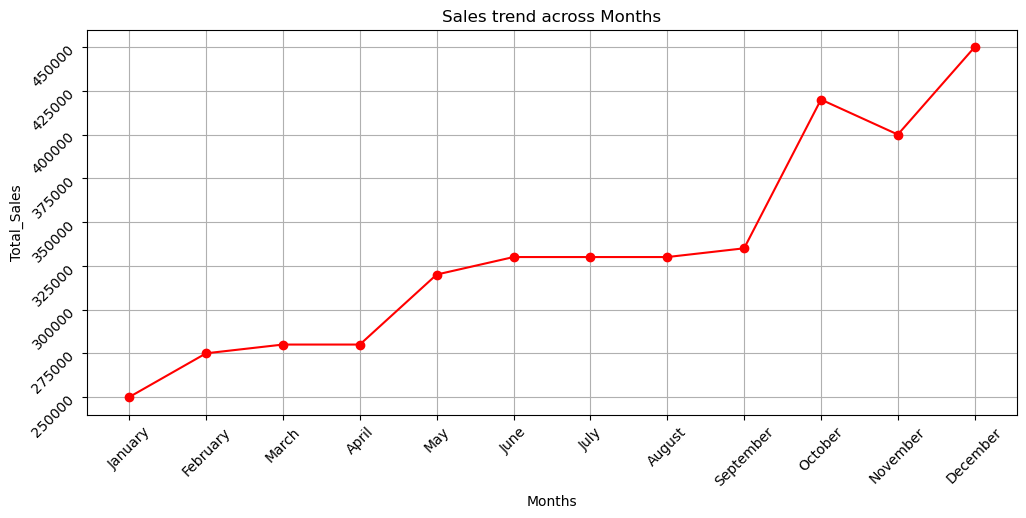

In [162]:
plt.figure(figsize=(12,5)) # to adjust the plot dimensions(height and width)
plt.plot(sales_df['Month'],sales_df['Total_Sales'],color='red',marker='o')
plt.xlabel('Months')
plt.ylabel('Total_Sales')
plt.title('Sales trend across Months')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.grid(visible=True)
plt.show()

In [173]:
data = {
    'Month': ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    'Mumbai_Sales': [240000,245000,245000,310000,310000,315000,450000,460000,455000,550000,540000,560000],
    'Delhi_Sales': [140000,130000,130000,210000,210000,220000,310000,320000,325000,150000,190000,120000],
}
df = pd.DataFrame(data)

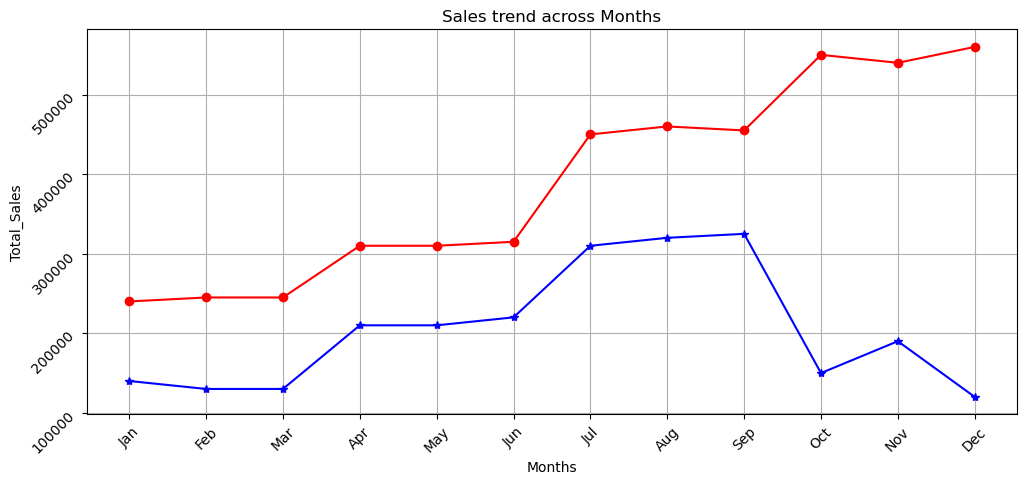

In [174]:
plt.figure(figsize=(12,5)) # to adjust the plot dimensions(height and width)
plt.plot(df['Month'],df['Mumbai_Sales'],color='red',marker='o')
plt.plot(df['Month'],df['Delhi_Sales'],color='blue',marker='*')
plt.xlabel('Months')
plt.ylabel('Total_Sales')
plt.title('Sales trend across Months')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.grid(visible=True)
plt.show()

#### Bar Plot

From here on lets use tips dataset for visualizing the plots 

In [177]:
import seaborn as sns 
tips = sns.load_dataset('tips')
tips.head(1)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2


In [178]:
tips['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

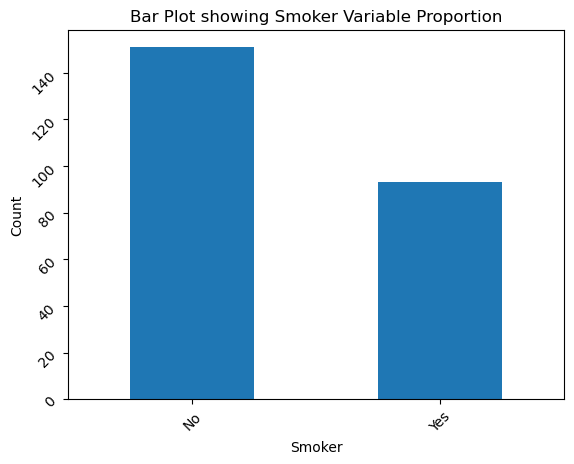

In [196]:
tips['smoker'].value_counts().plot(kind='bar')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.title('Bar Plot showing Smoker Variable Proportion')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

### Pie Chart

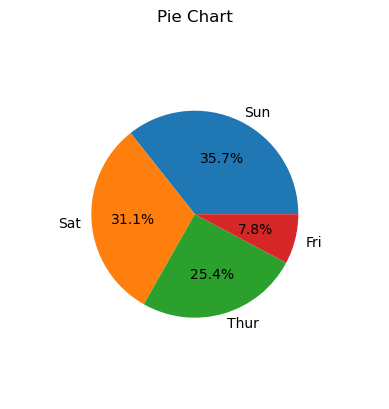

In [210]:
plt.pie(tips['day'].value_counts(), autopct = '%.1f%%', radius = 0.7, labels = tips['day'].unique())
plt.title('Pie Chart')
plt.show()

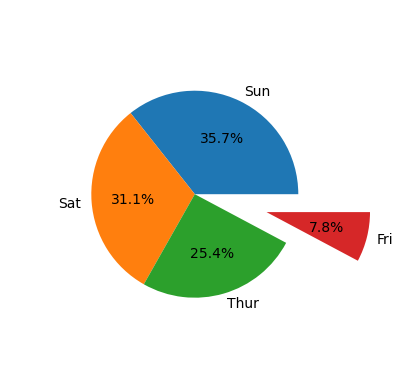

In [213]:
plt.pie(tips['day'].value_counts(), autopct = '%.1f%%', radius = 0.7, labels = tips['day'].unique(),explode = [0,0,0,0.5])
plt.show()

### Histogram

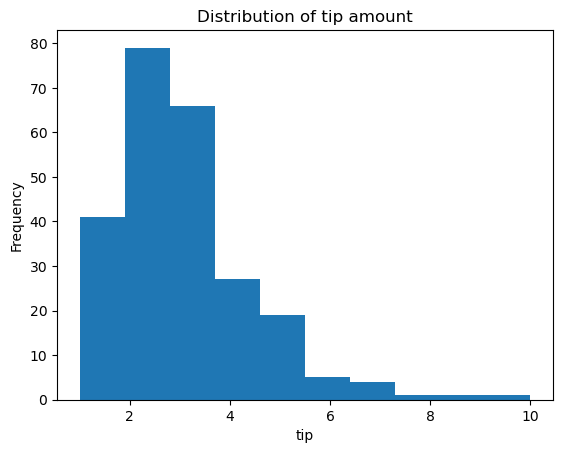

In [222]:
plt.hist(tips['tip'])
plt.title('Distribution of tip amount')
plt.xlabel('tip')
plt.ylabel('Frequency')
plt.show()

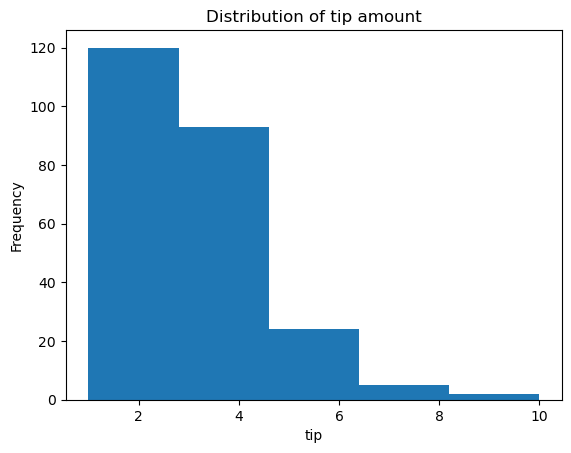

In [224]:
plt.hist(tips['tip'],bins=5) # we can control the number of bins
plt.title('Distribution of tip amount')
plt.xlabel('tip')
plt.ylabel('Frequency')
plt.show()

### Box Plot

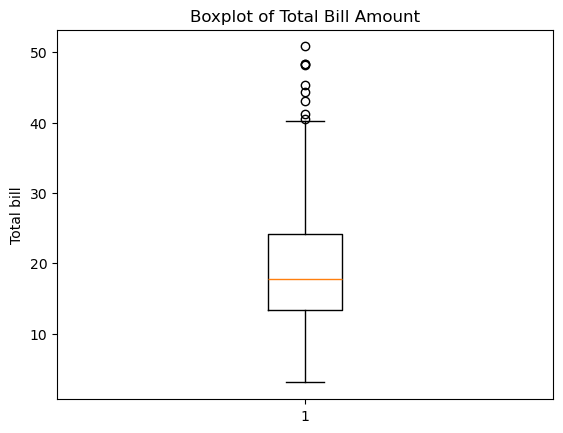

In [228]:
plt.boxplot(tips['total_bill'])
plt.title('Boxplot of Total Bill Amount')
plt.ylabel('Total bill')
plt.show()

### Scatter Plot

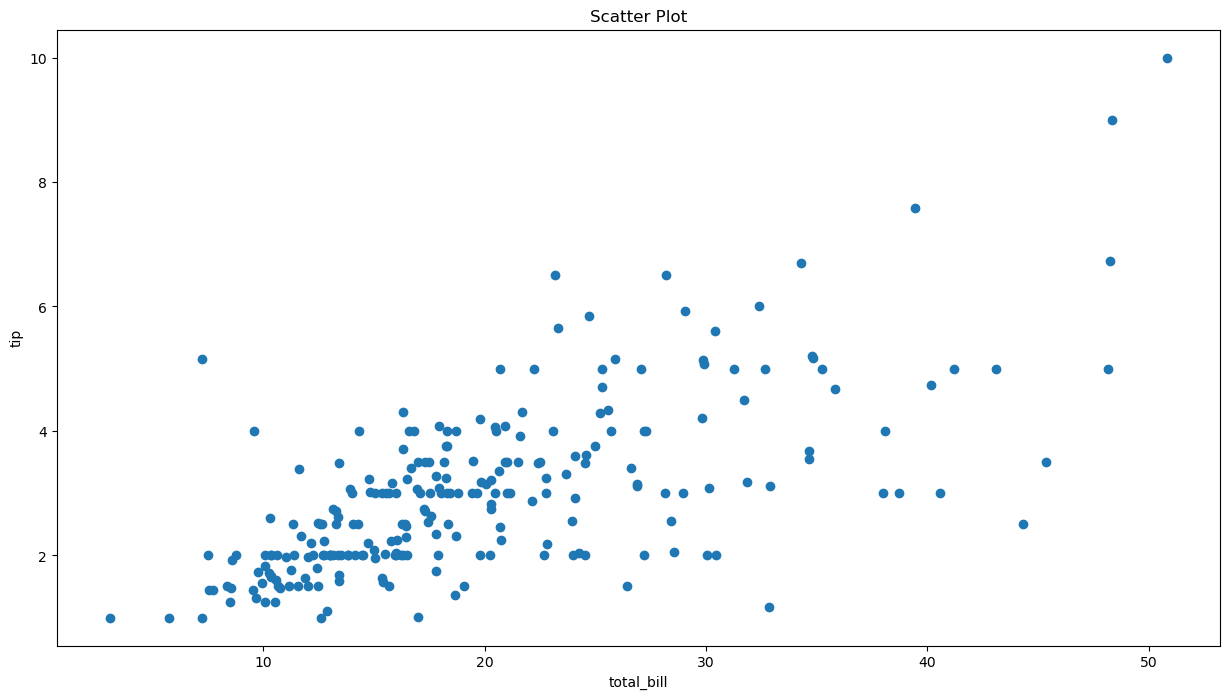

In [233]:
plt.figure(figsize=(15,8))
plt.scatter(x = tips['total_bill'],y = tips['tip'])
plt.title('Scatter Plot')
plt.xlabel('total_bill')
plt.ylabel('tip')
plt.show()

### Sub Plots / Multiple Plots

In [241]:
data = {
    'Units_Sold': [5,10,15,20,7,18,6,22,9,4],
    'Unit_Price': [60000,2000,1500,800,62000,1500,12000,900,2500,11000],
    'Total_Sales': [300000,20000,22500,16000,434000,27000,72000,19800,22500,44000]
}
df = pd.DataFrame(data)
df.head(1)

,Units_Sold,Unit_Price,Total_Sales
0,5,60000,300000


Text(0.5, 0.98, 'Boxplots of Sales Variables')

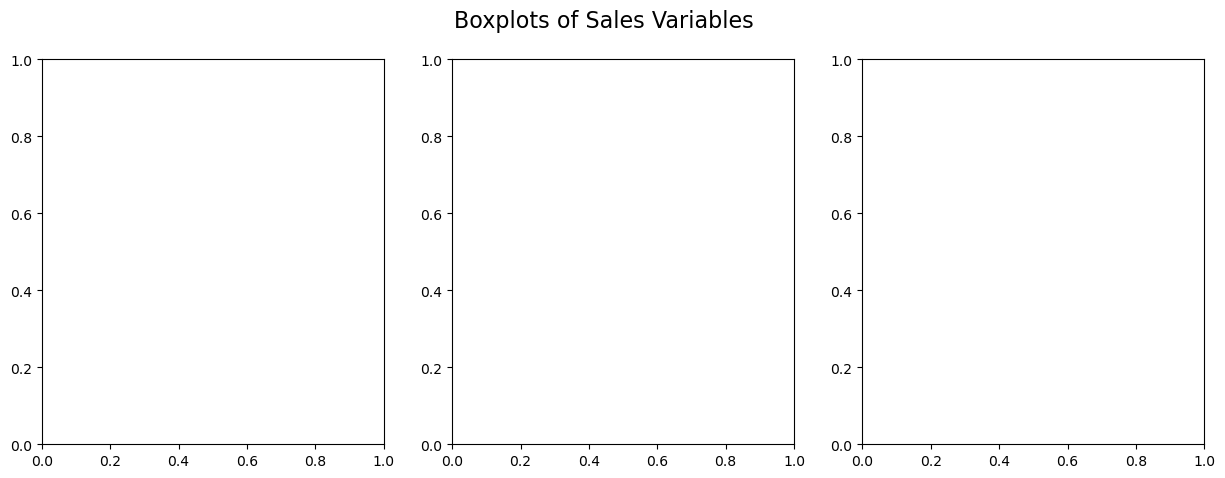

In [249]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))  #creates a figure (fig) with 1 row and 3 side-by-side subplots.
fig.suptitle('Boxplots of Sales Variables', fontsize=16) # This will set the title of subplots


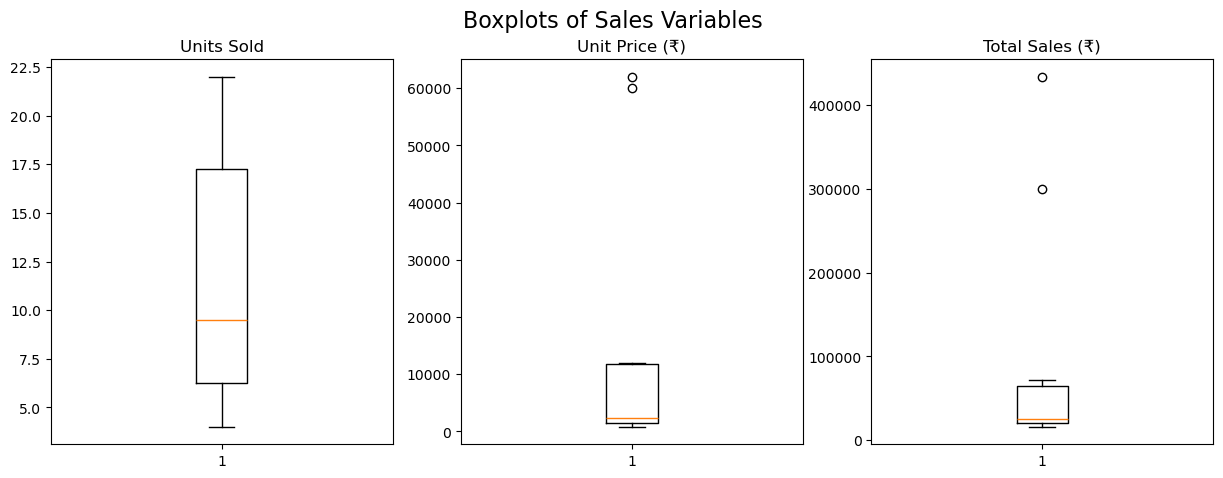

In [250]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))  #creates a figure (fig) with 1 row and 3 side-by-side subplots.
fig.suptitle('Boxplots of Sales Variables', fontsize=16) # This will set the title of subplots

# Boxplots for each variable
ax[0].boxplot(df['Units_Sold'])
ax[0].set_title('Units Sold')

ax[1].boxplot(df['Unit_Price'])
ax[1].set_title('Unit Price (₹)')

ax[2].boxplot(df['Total_Sales'])
ax[2].set_title('Total Sales (₹)')

plt.show()

<a id="seaborn"> </a>
### 15.Plots using Seaborn

Seaborn is a Python visualization library based on matplotlib. The library provides a high-level interface for plotting statistical graphics. As the library uses matplotlib in the backend, we can use the functions in matplotlib along with functions in seaborn.<br><br>
Various functions in the seaborn library allow us to plot complex and advance statistical plots such as linear/higher-order regression, univariate/multivariate distribution, violin, swarm, strip plots, correlations.

**How to install Seaborn?**<br>
1. You can use-<br>`!pip install seaborn`<br>

### Count Plot

Text(0.5, 1.0, 'Count Plot')

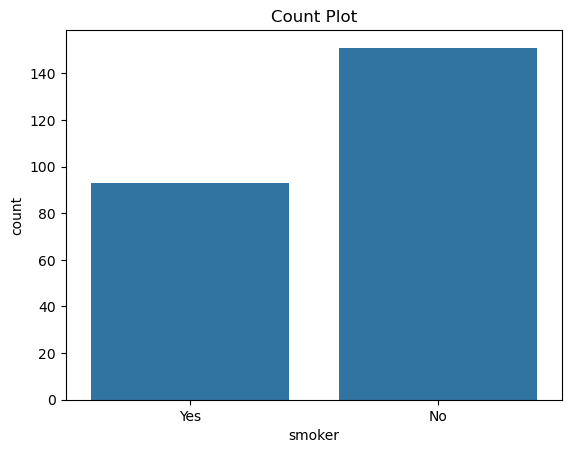

In [261]:
sns.countplot(x= tips['smoker'])
plt.title('Count Plot')

x → makes a vertical bar chart (x-axis categories, y-axis counts)

y → makes a horizontal bar chart (y-axis categories, x-axis counts)

hue → splits the bars by another category (colors)

Text(0.5, 1.0, 'Count Plot')

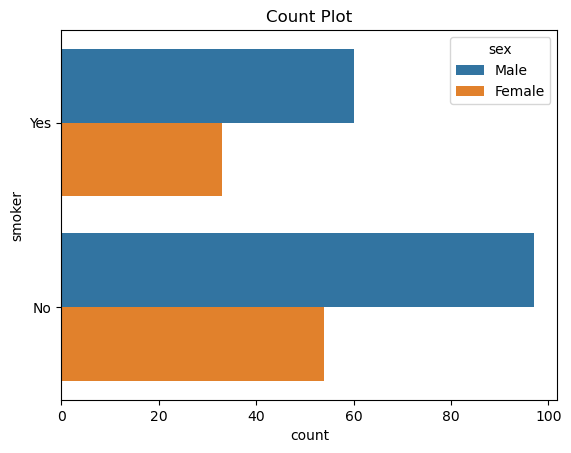

In [262]:
sns.countplot(y= tips['smoker'], hue= tips['sex'])
plt.title('Count Plot')

### hist Plot

<Axes: xlabel='tip', ylabel='Count'>

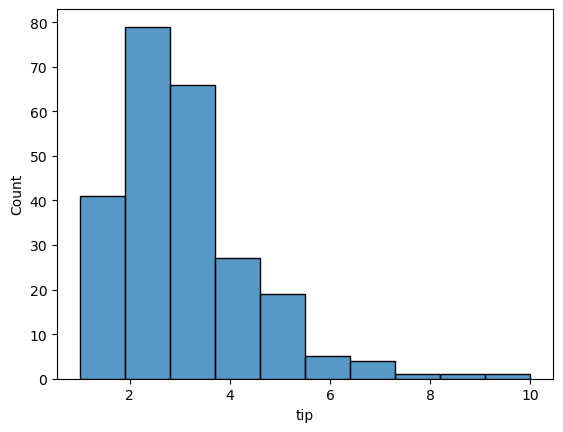

In [270]:
sns.histplot(tips['tip'],bins=10)

<Axes: xlabel='tip', ylabel='Count'>

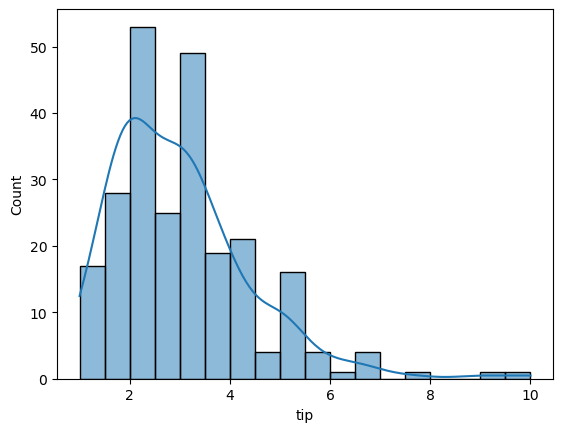

In [269]:
sns.histplot(tips['tip'],kde=True)

### Strip Plot

<Axes: xlabel='time', ylabel='tip'>

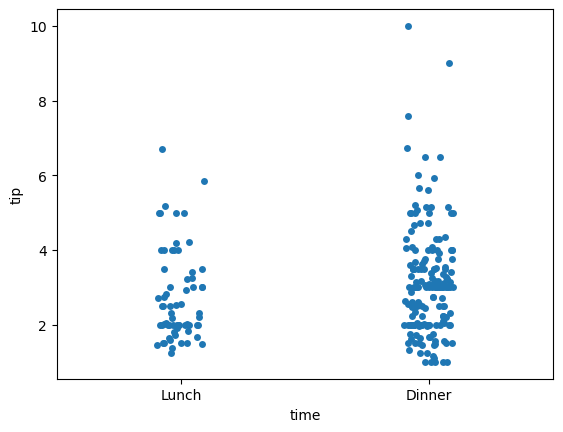

In [278]:
sns.stripplot(x = tips['time'], y = tips['tip'])

In [274]:
# Swarm Plot

<Axes: xlabel='time', ylabel='tip'>

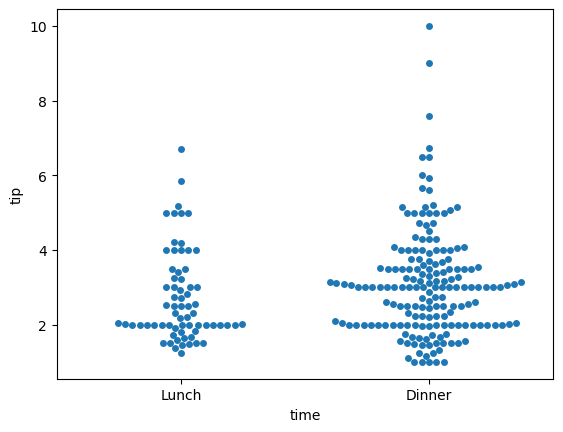

In [277]:
sns.swarmplot(x = tips['time'], y = tips['tip'])

### Box Plot

<Axes: ylabel='tip'>

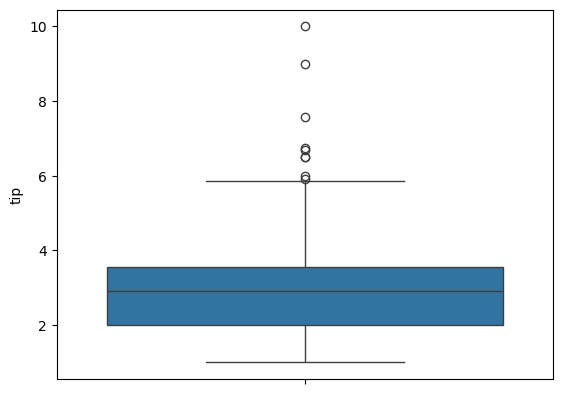

In [281]:
sns.boxplot(tips['tip'])

<Axes: ylabel='tip'>

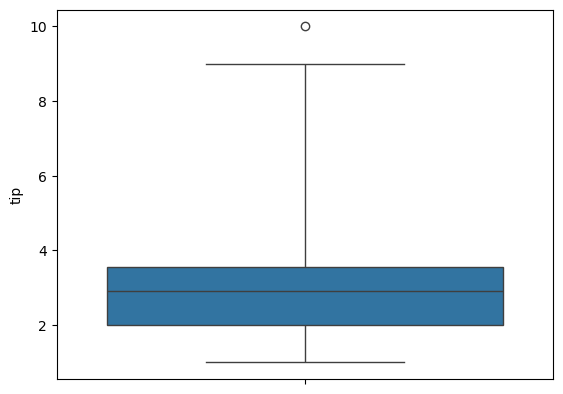

In [286]:
sns.boxplot(tips['tip'],whis=4) # whis = 4 will increase the UL & LL by 4*IQR

<Axes: xlabel='smoker', ylabel='tip'>

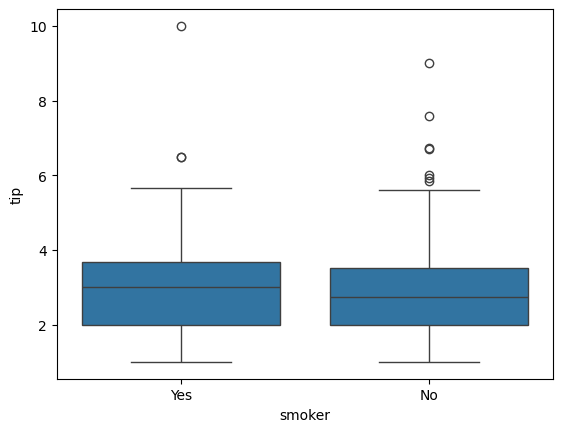

In [292]:
sns.boxplot(x=tips['smoker'],y=tips['tip']) # we can plot multiple box plots 

<Axes: xlabel='day', ylabel='tip'>

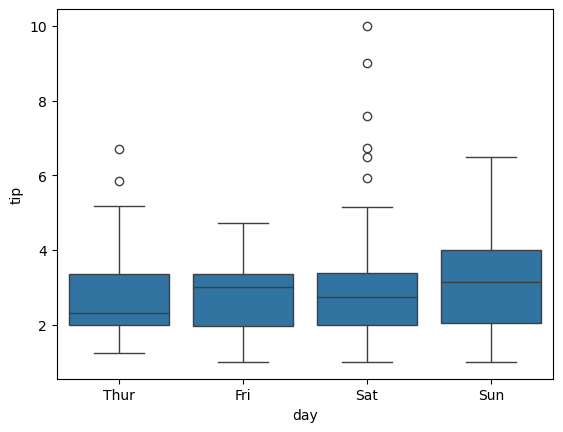

In [293]:
sns.boxplot(x=tips['day'],y=tips['tip'])

### Violin Plot

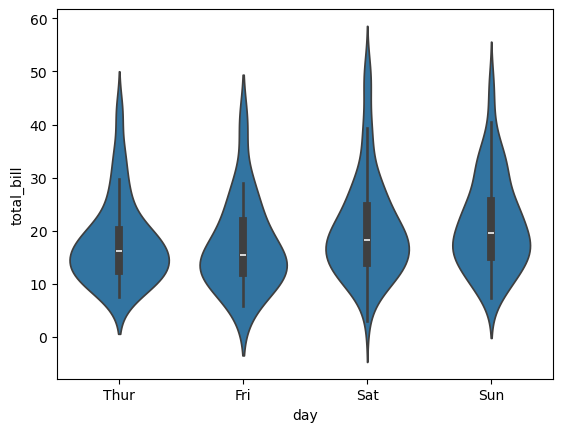

In [296]:
sns.violinplot(x = tips['day'],y = tips['total_bill'] )
plt.show()

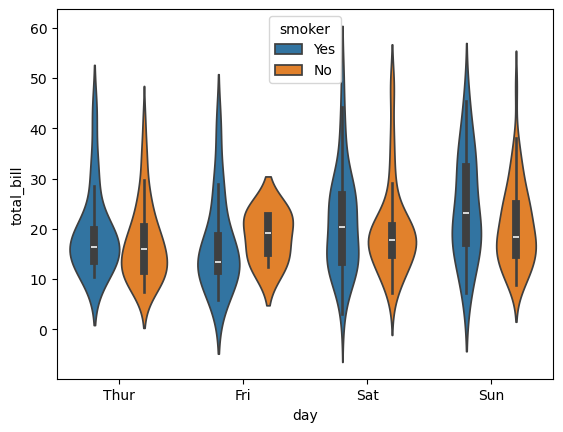

In [299]:
sns.violinplot(x = tips['day'],y = tips['total_bill'],hue=tips['smoker'])
plt.show()

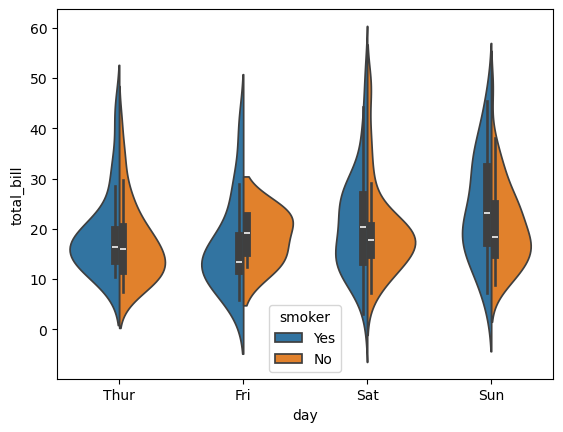

In [301]:
sns.violinplot(x = tips['day'],y = tips['total_bill'],hue=tips['smoker'],split=True)
plt.show()

### Scatter Plot

<Axes: xlabel='total_bill', ylabel='tip'>

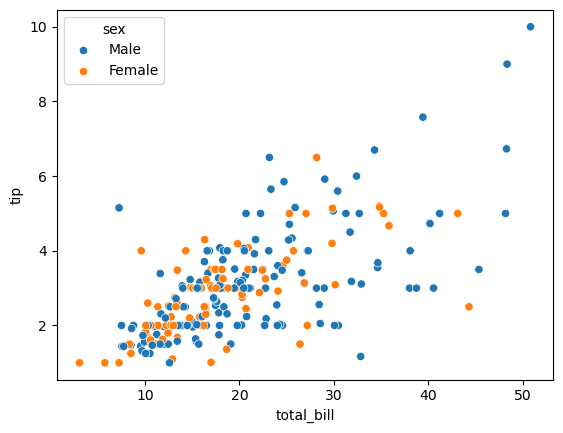

In [304]:
sns.scatterplot(x=tips['total_bill'],y=tips['tip'],hue=tips['sex'])

In [307]:
import pandas as pd

# Sample dataset
data = {
'Experience': [1, 2, 3, 1, 4, 5, 6, 2, 3, 7, 8, 9, 5, 6, 7, 10, 12, 8, 6, 4],
'Salary': [30000, 35000, 40000, 32000, 45000, 50000, 55000, 37000, 42000, 60000,65000, 70000, 52000, 58000, 62000, 75000, 80000, 68000, 60000, 45000],
'Designation': ['Associate','Associate','Associate','Associate','Associate','Associate','Manager','Associate','Associate','Manager',
'Manager','Manager','Manager','Manager','Manager','Manager','Manager','Manager','Manager','Associate']
}

df = pd.DataFrame(data)
df.head(1)


,Experience,Salary,Designation
0,1,30000,Associate


<Axes: xlabel='Experience', ylabel='Salary'>

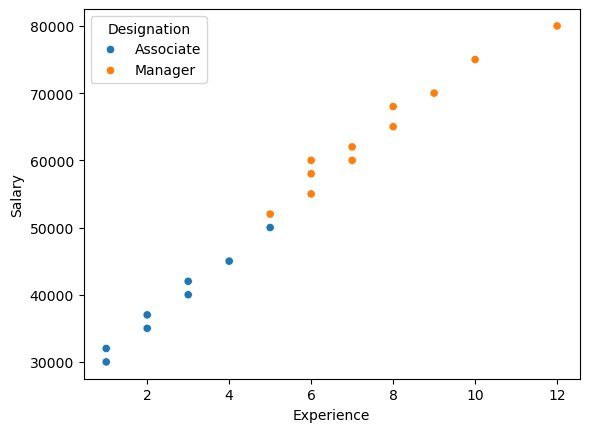

In [308]:
sns.scatterplot(x=df['Experience'],y=df['Salary'],hue=df['Designation'])

### Reg Plot

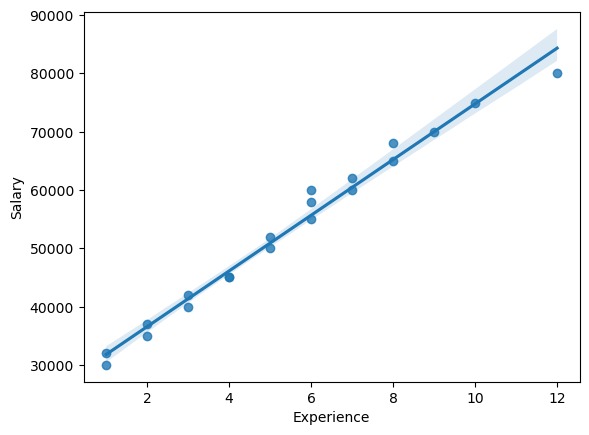

In [311]:
sns.regplot(x=df['Experience'],y=df['Salary'])
plt.show()

### Rel Plot

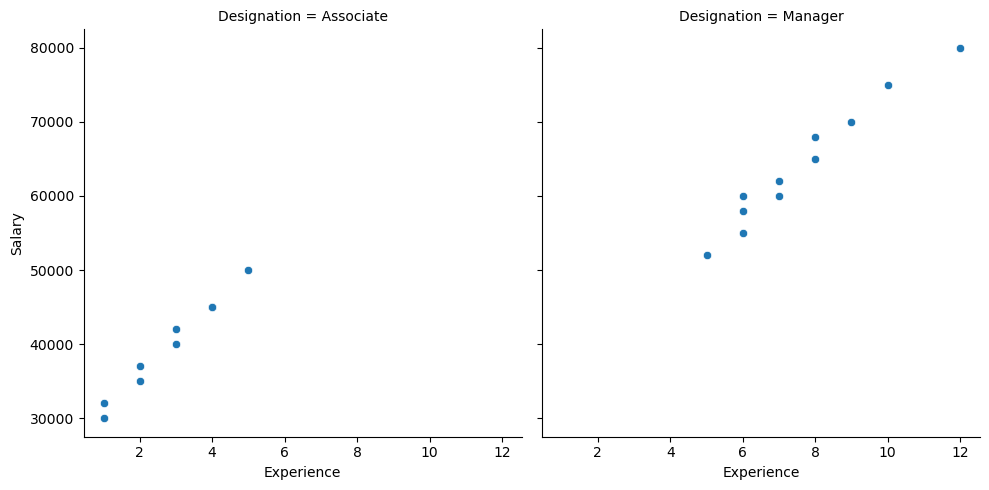

In [318]:
sns.relplot(x=df['Experience'],y=df['Salary'],col=df['Designation'])

### lmplot

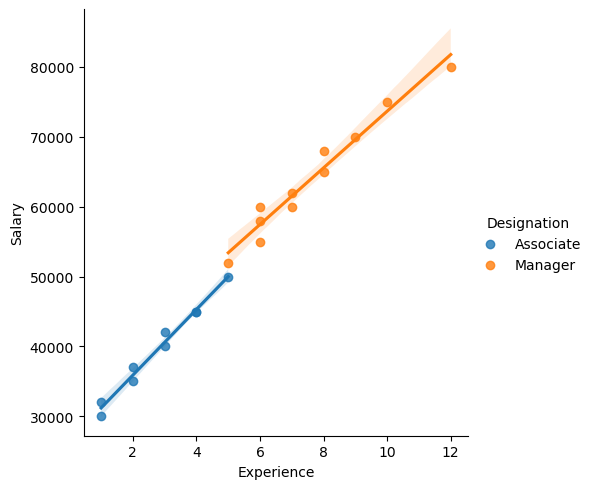

In [324]:
sns.lmplot(
    data=df,
    x='Experience', y='Salary',
    hue='Designation', # separate regression lines per designation
    )

### Pair Plot

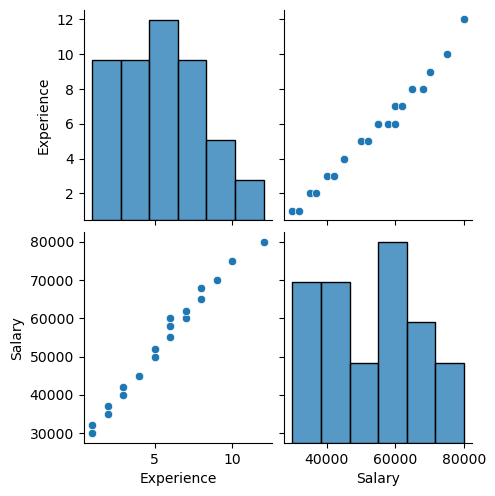

In [327]:
sns.pairplot(df)

<a id="plotly"> </a>
## 16. Plots using Plotly (3d Plots)
Plotly is a python library used to create interactive, publication-quality graphs. Plotly express provides more customizations for plots such as bar plots, histogram, pie plot.

**How to install Plotly?**<br>
1. You can use-<br>
`!pip install plotly`<br>

In [339]:
iris = sns.load_dataset('iris')
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


### Scatter Plot

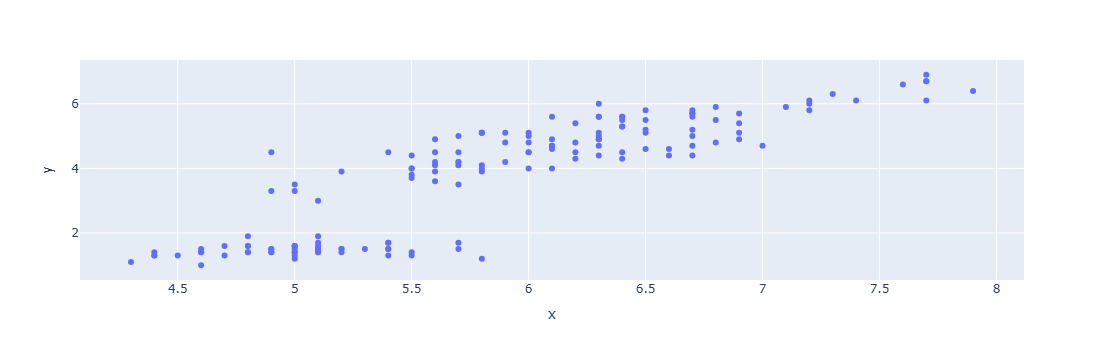

In [343]:
# import the library
import plotly.express as px

# data specifies the DataFrame to be used
# x specifies the variable on x-axis
# y specifies the variable on y-axis
fig = px.scatter(x= iris['sepal_length'], y= iris['petal_length'])

# display the plot
fig.show()

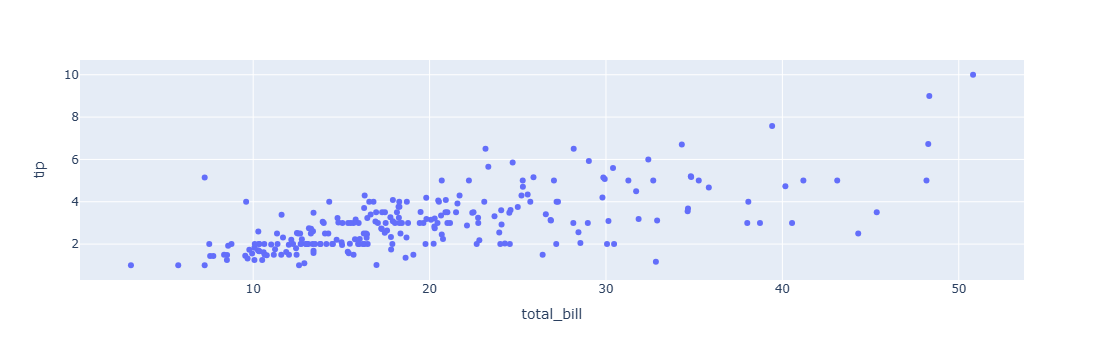

In [347]:
# import the library
import plotly.express as px
px.scatter(tips, x= tips['total_bill'], y= tips['tip'])

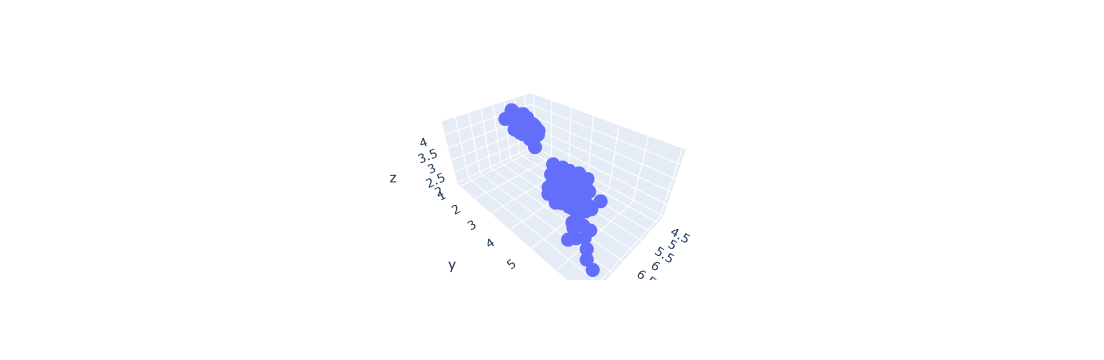

In [346]:
px.scatter_3d(x= iris['sepal_length'], y= iris['petal_length'],z=iris['sepal_width'])

### Histogram

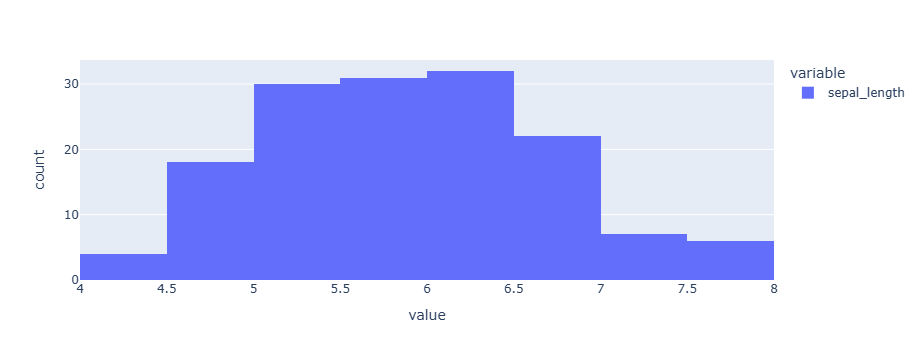

In [349]:
px.histogram(iris['sepal_length'])

### Bar

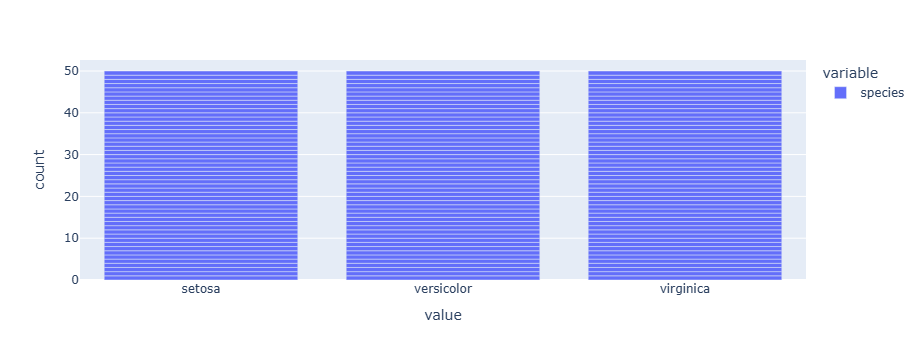

In [350]:
px.bar(iris['species'])

### Box

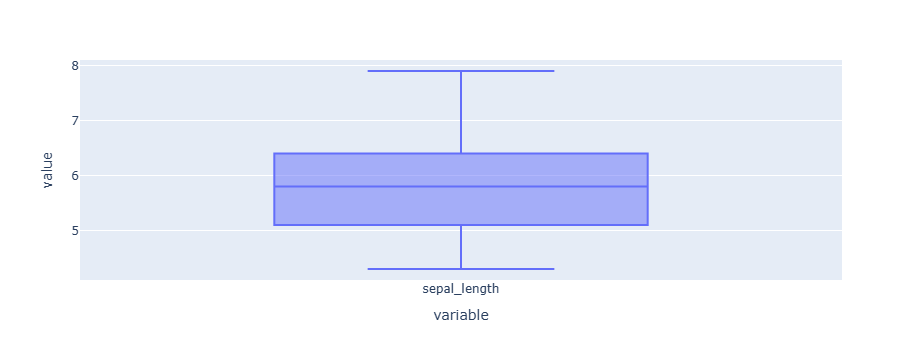

In [351]:
px.box(iris['sepal_length'])